# Basic GNN + Temperature dự đoán thermal conductivity

Notebook này được xây dựng tương tự notebook CGCNN gốc, nhưng thay lớp CGCNN bằng **GCNConv**, một lớp GNN cơ bản.

- **Node:** nguyên tử trong cấu trúc tinh thể.
- **Node feature:** embedding của số hiệu nguyên tử.
- **Edge:** quan hệ lân cận xác định từ CIF với bán kính cắt `R_CUT`.
- **Graph feature:** trung bình đặc trưng của tất cả nguyên tử sau message passing.
- **Global feature:** Temperature (K), được ghép sau graph pooling.
- **Target:** TC (W m⁻¹ K⁻¹).

Khác với CGCNN, mô hình GNN cơ bản này **không sử dụng Gaussian expansion của khoảng cách liên nguyên tử** trong phép convolution. Khoảng cách chỉ được dùng để xác định các cạnh của graph.


In [1]:
# Cell 1 - Cài thư viện nếu chạy trên Google Colab
import sys
import subprocess
import importlib.util


def pip_install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


if importlib.util.find_spec("ase") is None:
    pip_install("ase")

if importlib.util.find_spec("torch_geometric") is None:
    pip_install("torch-geometric")

print("Done")


Done


In [2]:
# Cell 2 - Import và cố định random seed
import os
import re
import glob
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from ase.io import read
from ase.neighborlist import neighbor_list

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
# Cell 3 - Cấu hình đường dẫn và tham số
# Đặt notebook, CSV và folder CIF trong cùng một thư mục rồi sửa hai dòng dưới nếu cần.
CSV_PATH = r"C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\mp_cif_matched_data_TE.csv"
CIF_FOLDER = r"C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\downloaded_cif_TE"

# Graph construction
R_CUT = 6.0
MAX_NEIGHBORS = 12

# Chia dữ liệu:
# "row"       : random 80/10/10 như notebook CGCNN gốc.
# "structure" : một identifier/CIF chỉ xuất hiện trong một tập dữ liệu.
SPLIT_MODE = "row"

# Đặt số nguyên để chạy thử nhanh; dùng None khi chạy toàn bộ dữ liệu.
MAX_ROWS = None

# Training
BATCH_SIZE = 64
EPOCHS = 1000
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

print("CSV_PATH:", CSV_PATH)
print("CIF_FOLDER:", CIF_FOLDER)
print("SPLIT_MODE:", SPLIT_MODE)


CSV_PATH: C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\mp_cif_matched_data_TE.csv
CIF_FOLDER: C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\downloaded_cif_TE
SPLIT_MODE: row


In [4]:
# Cell 4 - Đọc và làm sạch dữ liệu
df = pd.read_csv(CSV_PATH)

required_cols = ["identifier", "formula", "Temperature (K)", "TC", "cif_path"]
missing_cols = [column for column in required_cols if column not in df.columns]

if missing_cols:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_cols}")

df = df.dropna(subset=required_cols).copy()
df["Temperature (K)"] = pd.to_numeric(df["Temperature (K)"], errors="coerce")
df["TC"] = pd.to_numeric(df["TC"], errors="coerce")
df = df.dropna(subset=["Temperature (K)", "TC"]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Unique identifiers:", df["identifier"].nunique())
print("Unique formulas:", df["formula"].nunique())
display(df.head())


Shape after cleaning: (707, 10)
Unique identifiers: 43
Unique formulas: 43


,identifier,formula,atoms,num_atoms,Formula_original,Temperature (K),TC,DOI,formation_energy_per_atom,cif_path
0,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,295.0,1.03,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
1,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,346.0,0.89,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
2,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,400.0,0.78,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
3,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,449.0,0.72,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
4,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,500.0,0.67,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif


,Temperature (K),TC
count,707.000000,707.000000
mean,461.818027,2.616016
std,212.021098,3.301871
min,5.000000,0.220000
25%,323.000000,0.695000
50%,448.364000,1.180000
75%,617.210500,3.221175
max,1176.092000,30.450000


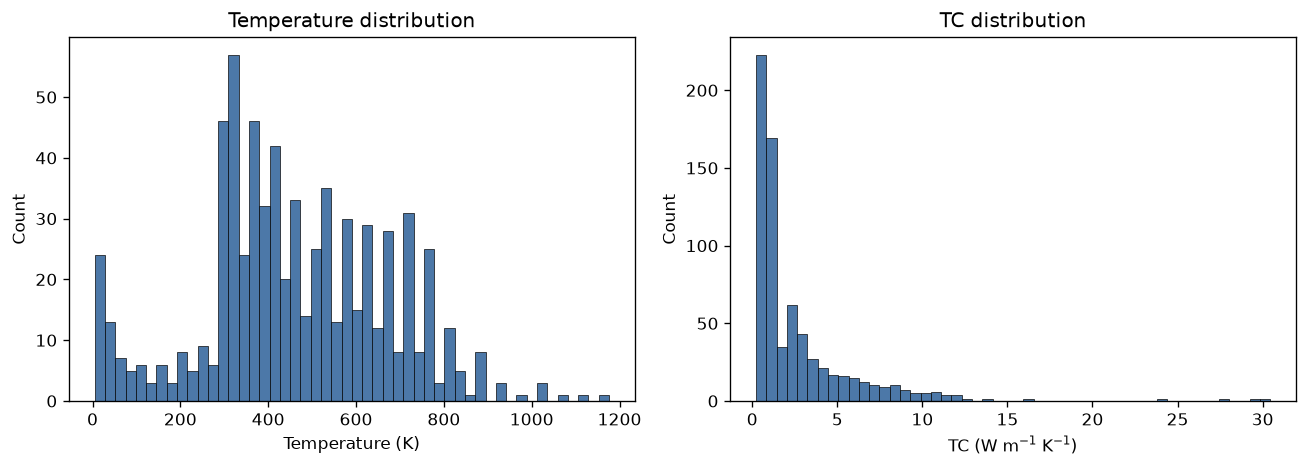

In [5]:
# Cell 5 - Thống kê dữ liệu
display(df[["Temperature (K)", "TC"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

axes[0].hist(df["Temperature (K)"], bins=50, color="#4C78A8", edgecolor="black", linewidth=0.4)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Count")
axes[0].set_title("Temperature distribution")

axes[1].hist(df["TC"], bins=50, color="#4C78A8", edgecolor="black", linewidth=0.4)
axes[1].set_xlabel(r"TC (W m$^{-1}$ K$^{-1}$)")
axes[1].set_ylabel("Count")
axes[1].set_title("TC distribution")

plt.tight_layout()
plt.show()


In [6]:
# Cell 6 - Tìm đúng file CIF
all_cif_files = glob.glob(os.path.join(CIF_FOLDER, "*.cif"))
mpid_to_cif = {}

for path in all_cif_files:
    match = re.search(r"mp-\d+", os.path.basename(path))
    if match:
        mpid_to_cif[match.group()] = path

print("Number of CIF files:", len(all_cif_files))
print("Number of mp-id values found:", len(mpid_to_cif))


def portable_basename(path):
    # Lấy tên file từ cả đường dẫn Windows và Linux.
    return re.split(r"[\\/]", str(path))[-1]


def resolve_cif_path(row):
    identifier = str(row["identifier"]).strip()
    raw_cif_path = str(row["cif_path"]).strip()
    normalized_path = raw_cif_path.replace("\\", os.sep).replace("/", os.sep)
    basename = portable_basename(raw_cif_path)

    candidates = [
        raw_cif_path,
        normalized_path,
        os.path.join(os.path.dirname(os.path.abspath(CSV_PATH)), normalized_path),
        os.path.join(CIF_FOLDER, basename),
        os.path.join("/content", normalized_path),
        os.path.join("/content", basename),
    ]

    for candidate in candidates:
        if os.path.exists(candidate):
            return os.path.abspath(candidate)

    for text in (identifier, raw_cif_path):
        match = re.search(r"mp-\d+", text)
        if match and match.group() in mpid_to_cif:
            return os.path.abspath(mpid_to_cif[match.group()])

    return None


df["resolved_cif_path"] = df.apply(resolve_cif_path, axis=1)

missing_mask = df["resolved_cif_path"].isna()
print("Rows with existing CIF:", (~missing_mask).sum())
print("Rows missing CIF:", missing_mask.sum())

if missing_mask.any():
    display(
        df.loc[missing_mask, ["identifier", "formula", "cif_path"]]
        .drop_duplicates()
        .head(30)
    )


Number of CIF files: 43
Number of mp-id values found: 43
Rows with existing CIF: 707
Rows missing CIF: 0


In [7]:
# Cell 7 - Chỉ giữ các dòng có CIF tồn tại
df = df[df["resolved_cif_path"].notna()].reset_index(drop=True)

if len(df) == 0:
    raise ValueError("Không còn dòng nào có CIF. Hãy kiểm tra lại CSV_PATH và CIF_FOLDER.")

if MAX_ROWS is not None:
    df_work = df.sample(n=min(MAX_ROWS, len(df)), random_state=SEED).reset_index(drop=True)
else:
    df_work = df.copy().reset_index(drop=True)

# Không scale Temperature và TC, giống notebook CGCNN gốc.
df_work["temp_input"] = df_work["Temperature (K)"].astype(float)
df_work["tc_target"] = df_work["TC"].astype(float)

print("Rows used:", len(df_work))
print("Unique CIF structures:", df_work["identifier"].nunique())
display(df_work[["identifier", "formula", "Temperature (K)", "TC", "resolved_cif_path"]].head())


Rows used: 707
Unique CIF structures: 43


,identifier,formula,Temperature (K),TC,resolved_cif_path
0,mp-691,SnSe,295.0,1.03,c:\Users\Admin\Downloads\TC alloys and TE CGCN...
1,mp-691,SnSe,346.0,0.89,c:\Users\Admin\Downloads\TC alloys and TE CGCN...
2,mp-691,SnSe,400.0,0.78,c:\Users\Admin\Downloads\TC alloys and TE CGCN...
3,mp-691,SnSe,449.0,0.72,c:\Users\Admin\Downloads\TC alloys and TE CGCN...
4,mp-691,SnSe,500.0,0.67,c:\Users\Admin\Downloads\TC alloys and TE CGCN...


In [8]:
# Cell 8 - Chuyển cấu trúc ASE thành graph
# Basic GNN dùng edge_index để biểu diễn adjacency.
# edge_length vẫn được lưu để kiểm tra, nhưng không được đưa vào GCNConv.


def atoms_to_graph(atoms, r_cut=6.0, max_neighbors=12):
    center, neighbor, distance = neighbor_list(
        "ijd",
        atoms,
        cutoff=r_cut,
        self_interaction=False,
    )

    if len(center) == 0:
        raise ValueError("Không tìm được nguyên tử lân cận trong bán kính cắt")

    center = np.asarray(center)
    neighbor = np.asarray(neighbor)
    distance = np.asarray(distance)

    if max_neighbors is not None:
        keep = []
        for atom_index in np.unique(center):
            positions = np.where(center == atom_index)[0]
            nearest = positions[np.argsort(distance[positions])[:max_neighbors]]
            keep.extend(nearest.tolist())

        keep = np.asarray(keep, dtype=int)
        center = center[keep]
        neighbor = neighbor[keep]
        distance = distance[keep]

    return Data(
        numbers=torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long),
        edge_index=torch.tensor(np.vstack([center, neighbor]), dtype=torch.long),
        edge_length=torch.tensor(distance, dtype=torch.float32),
        num_nodes=len(atoms),
    )


In [9]:
# Cell 9 - Tạo dataset graph và cache graph theo CIF
base_graph_cache = {}
data_list = []
failed_rows = []

for row_id, row in df_work.iterrows():
    try:
        cif_path = row["resolved_cif_path"]

        if cif_path not in base_graph_cache:
            atoms = read(cif_path)
            base_graph_cache[cif_path] = atoms_to_graph(
                atoms,
                r_cut=R_CUT,
                max_neighbors=MAX_NEIGHBORS,
            )

        graph = base_graph_cache[cif_path].clone()
        graph.temperature = torch.tensor([row["temp_input"]], dtype=torch.float32)
        graph.y = torch.tensor([row["tc_target"]], dtype=torch.float32)
        graph.row_id = torch.tensor([row_id], dtype=torch.long)
        data_list.append(graph)

    except Exception as error:
        failed_rows.append((row_id, row["identifier"], row["formula"], str(error)))

    if (row_id + 1) % 500 == 0:
        print(f"Processed {row_id + 1}/{len(df_work)}")

print("Successful graph samples:", len(data_list))
print("Failed rows:", len(failed_rows))
print("Unique base graphs:", len(base_graph_cache))

if failed_rows:
    failed_df = pd.DataFrame(
        failed_rows,
        columns=["row_id", "identifier", "formula", "error"],
    )
    display(failed_df.head(30))

if not data_list:
    raise ValueError("Không tạo được graph nào từ các file CIF.")

torch.save(data_list, "basic_gnn_tc_graphs.pt")
print("Saved: basic_gnn_tc_graphs.pt")


Processed 500/707
Successful graph samples: 707
Failed rows: 0
Unique base graphs: 43
Saved: basic_gnn_tc_graphs.pt


In [10]:
# Cell 10 - Kiểm tra một graph
sample = data_list[0]
print(sample)
print("numbers shape:", sample.numbers.shape)
print("edge_index shape:", sample.edge_index.shape)
print("edge_length shape:", sample.edge_length.shape)
print("temperature:", sample.temperature)
print("target TC:", sample.y)
print("row_id:", sample.row_id)


Data(edge_index=[2, 96], numbers=[8], edge_length=[96], num_nodes=8, temperature=[1], y=[1], row_id=[1])
numbers shape: torch.Size([8])
edge_index shape: torch.Size([2, 96])
edge_length shape: torch.Size([96])
temperature: tensor([295.])
target TC: tensor([1.0300])
row_id: tensor([0])


In [11]:
# Cell 11 - Chia train/validation/test theo tỷ lệ 80/10/10


def subset(items, indices):
    return [items[index] for index in indices]


all_indices = np.arange(len(data_list))

if SPLIT_MODE == "row":
    train_indices, remaining_indices = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=SEED,
        shuffle=True,
    )
    val_indices, test_indices = train_test_split(
        remaining_indices,
        test_size=0.50,
        random_state=SEED,
        shuffle=True,
    )

elif SPLIT_MODE == "structure":
    successful_row_ids = np.array([int(graph.row_id.item()) for graph in data_list])
    sample_groups = df_work.iloc[successful_row_ids]["identifier"].astype(str).to_numpy()
    unique_groups = np.unique(sample_groups)

    if len(unique_groups) < 10:
        raise ValueError("Cần ít nhất 10 cấu trúc để dùng SPLIT_MODE='structure'.")

    train_groups, remaining_groups = train_test_split(
        unique_groups,
        test_size=0.20,
        random_state=SEED,
        shuffle=True,
    )
    val_groups, test_groups = train_test_split(
        remaining_groups,
        test_size=0.50,
        random_state=SEED,
        shuffle=True,
    )

    train_indices = all_indices[np.isin(sample_groups, train_groups)]
    val_indices = all_indices[np.isin(sample_groups, val_groups)]
    test_indices = all_indices[np.isin(sample_groups, test_groups)]

else:
    raise ValueError("SPLIT_MODE phải là 'row' hoặc 'structure'.")

train_data = subset(data_list, train_indices)
val_data = subset(data_list, val_indices)
test_data = subset(data_list, test_indices)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

if SPLIT_MODE == "structure":
    train_ids = set(df_work.iloc[[int(g.row_id.item()) for g in train_data]]["identifier"])
    val_ids = set(df_work.iloc[[int(g.row_id.item()) for g in val_data]]["identifier"])
    test_ids = set(df_work.iloc[[int(g.row_id.item()) for g in test_data]]["identifier"])
    assert train_ids.isdisjoint(val_ids)
    assert train_ids.isdisjoint(test_ids)
    assert val_ids.isdisjoint(test_ids)
    print("No identifier overlap between train/validation/test.")


Train: 565
Validation: 71
Test: 71


In [12]:
# Cell 12 - DataLoader
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_eval_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(batch)
print("Number of graphs in batch:", batch.num_graphs)
print("numbers shape:", batch.numbers.shape)
print("edge_index shape:", batch.edge_index.shape)
print("batch vector shape:", batch.batch.shape)
print("temperature shape:", batch.temperature.shape)
print("target shape:", batch.y.shape)


DataBatch(edge_index=[2, 9048], numbers=[754], edge_length=[9048], num_nodes=754, temperature=[64], y=[64], row_id=[64], batch=[754], ptr=[65])
Number of graphs in batch: 64
numbers shape: torch.Size([754])
edge_index shape: torch.Size([2, 9048])
batch vector shape: torch.Size([754])
temperature shape: torch.Size([64])
target shape: torch.Size([64])


## Mô hình Basic GNN

Mỗi lớp `GCNConv` thực hiện message passing dựa trên ma trận kề đã chuẩn hóa. Sau ba lớp convolution, `global_mean_pool` chuyển các đặc trưng nguyên tử thành một vector đại diện cho toàn bộ tinh thể. Temperature được ghép với vector này trước các fully connected layers.


In [13]:
# Cell 13 - Basic GNN + Temperature
class BasicGNNWithTemperature(nn.Module):
    def __init__(
        self,
        num_atom_types=119,
        hidden_dim=64,
        num_gnn_layers=3,
        mlp_hidden_dim=128,
        dropout=0.10,
    ):
        super().__init__()

        self.atom_embedding = nn.Embedding(num_atom_types, hidden_dim)
        self.convs = nn.ModuleList(
            [GCNConv(hidden_dim, hidden_dim) for _ in range(num_gnn_layers)]
        )
        self.norms = nn.ModuleList(
            [nn.BatchNorm1d(hidden_dim) for _ in range(num_gnn_layers)]
        )
        self.dropout = dropout

        self.fc1 = nn.Linear(hidden_dim + 1, mlp_hidden_dim)
        self.fc2 = nn.Linear(mlp_hidden_dim, mlp_hidden_dim // 2)
        self.fc_out = nn.Linear(mlp_hidden_dim // 2, 1)

    def forward(self, batch):
        x = self.atom_embedding(batch.numbers)

        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, batch.edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        graph_features = global_mean_pool(x, batch.batch)
        temperature = batch.temperature.view(-1, 1).to(graph_features.device)

        features = torch.cat([graph_features, temperature], dim=1)
        features = F.relu(self.fc1(features))
        features = F.dropout(features, p=self.dropout, training=self.training)
        features = F.relu(self.fc2(features))
        prediction = self.fc_out(features)

        return prediction.view(-1)


In [14]:
# Cell 14 - Khởi tạo mô hình
model = BasicGNNWithTemperature(
    num_atom_types=119,
    hidden_dim=64,
    num_gnn_layers=3,
    mlp_hidden_dim=128,
    dropout=0.10,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history = {"train_loss": [], "val_loss": []}
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


BasicGNNWithTemperature(
  (atom_embedding): Embedding(119, 64)
  (convs): ModuleList(
    (0-2): 3 x GCNConv(64, 64)
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=65, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 37249


In [15]:
# Cell 15 - Hàm train và evaluate
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        prediction = model(batch)
        target = batch.y.view(-1).float()
        loss = criterion(prediction, target)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        prediction = model(batch)
        target = batch.y.view(-1).float()
        loss = criterion(prediction, target)
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


In [16]:
# Cell 16 - Training loop
# Chạy đủ EPOCHS và lưu checkpoint có validation loss thấp nhất.
best_val_loss = np.inf
best_epoch = 0
best_model_path = "best_basic_gnn_tc_temperature.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:04d} | "
            f"Train loss: {train_loss:.6f} | "
            f"Validation loss: {val_loss:.6f}"
        )

model.load_state_dict(torch.load(best_model_path, map_location=device))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Saved:", best_model_path)


Epoch 0001 | Train loss: 18.955227 | Validation loss: 21.844944
Epoch 0005 | Train loss: 10.360825 | Validation loss: 14.843445
Epoch 0010 | Train loss: 3.660441 | Validation loss: 3.208275
Epoch 0015 | Train loss: 2.796309 | Validation loss: 2.861638
Epoch 0020 | Train loss: 2.675055 | Validation loss: 2.670131
Epoch 0025 | Train loss: 2.757410 | Validation loss: 3.428243
Epoch 0030 | Train loss: 1.826202 | Validation loss: 3.264670
Epoch 0035 | Train loss: 1.810588 | Validation loss: 2.810460
Epoch 0040 | Train loss: 1.545207 | Validation loss: 3.350202
Epoch 0045 | Train loss: 1.533001 | Validation loss: 3.512423
Epoch 0050 | Train loss: 1.882781 | Validation loss: 3.104477
Epoch 0055 | Train loss: 1.551513 | Validation loss: 2.508235
Epoch 0060 | Train loss: 1.577470 | Validation loss: 3.491870
Epoch 0065 | Train loss: 1.495395 | Validation loss: 3.366916
Epoch 0070 | Train loss: 1.067104 | Validation loss: 2.252076
Epoch 0075 | Train loss: 1.280731 | Validation loss: 1.671201
Epoc

In [ ]:
# Cell 17 - Lưu loss theo epoch và vẽ training curve
loss_history_df = pd.DataFrame({
    "Epoch": np.arange(1, len(history["train_loss"]) + 1),
    "Training_loss": history["train_loss"],
    "Validation_loss": history["val_loss"],
})
loss_history_df.to_csv("Basic_GNN_loss_by_epoch.csv", index=False)

plt.figure(figsize=(6, 4), dpi=120)
plt.plot(loss_history_df["Epoch"], loss_history_df["Training_loss"], label="Train loss", color="#4C78A8")
plt.plot(loss_history_df["Epoch"], loss_history_df["Validation_loss"], label="Validation loss", color="#E45756")
plt.axvline(best_epoch, color="black", linestyle=":", linewidth=1.2, label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Basic GNN training curve")
plt.legend()
plt.tight_layout()
plt.savefig("basic_gnn_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Basic_GNN_loss_by_epoch.csv")
print("Saved: basic_gnn_loss_curve.png")


In [18]:
# Cell 18 - Dự đoán và tính metrics
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    predictions = []
    targets = []
    row_ids = []

    for batch in loader:
        batch = batch.to(device)
        prediction = model(batch).view(-1)

        predictions.extend(prediction.cpu().numpy())
        targets.extend(batch.y.view(-1).cpu().numpy())
        row_ids.extend(batch.row_id.view(-1).cpu().numpy())

    y_true = np.asarray(targets, dtype=float)
    y_pred = np.asarray(predictions, dtype=float)
    row_ids = np.asarray(row_ids, dtype=int)

    # TC không âm; chỉ clip khi báo cáo, giống notebook CGCNN gốc.
    y_pred = np.clip(y_pred, a_min=0.0, a_max=None)
    return y_true, y_pred, row_ids


def metric_row(dataset_name, y_true, y_pred):
    return {
        "Dataset": dataset_name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


prediction_sets = {
    "Train": predict_loader(model, train_eval_loader),
    "Validation": predict_loader(model, val_loader),
    "Test": predict_loader(model, test_loader),
}

metrics_df = pd.DataFrame([
    metric_row(name, values[0], values[1])
    for name, values in prediction_sets.items()
])

display(metrics_df.round(6))


,Dataset,R2,RMSE,MAE
0,Train,0.935481,0.764682,0.404194
1,Validation,0.974456,0.675618,0.377970
2,Test,0.980965,0.590138,0.343386


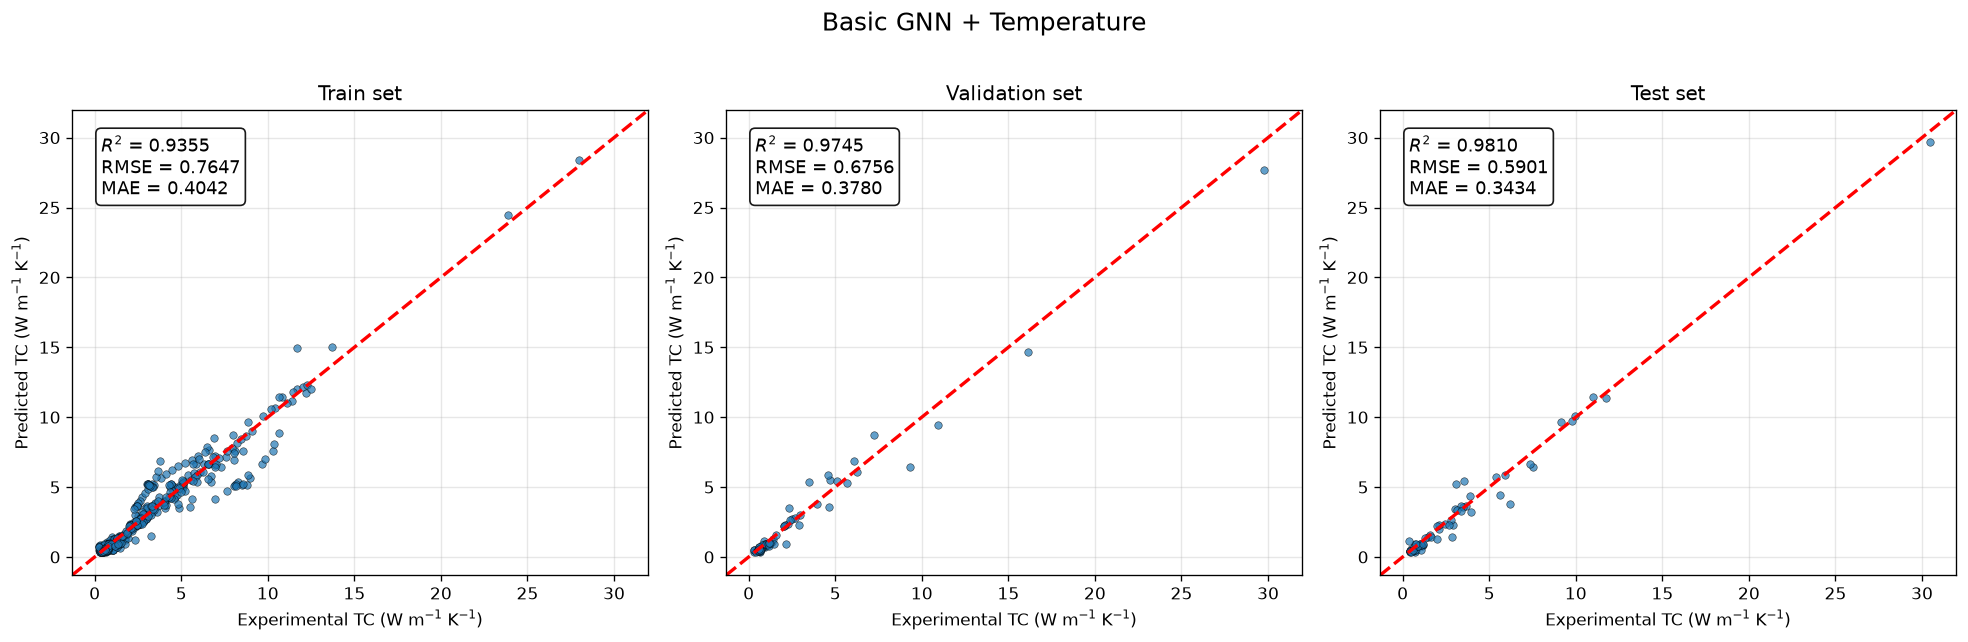

Saved: basic_gnn_parity_train_valid_test.png


In [19]:
# Cell 19 - Parity plots cho Train, Validation và Test
all_values = np.concatenate([
    values
    for y_true, y_pred, _ in prediction_sets.values()
    for values in (y_true, y_pred)
])

minimum = all_values.min()
maximum = all_values.max()
data_range = max(maximum - minimum, 1e-8)
padding = 0.05 * data_range
plot_min = minimum - padding
plot_max = maximum + padding

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), dpi=120)

for ax, (dataset_name, (y_true, y_pred, _)) in zip(axes, prediction_sets.items()):
    metrics = metric_row(dataset_name, y_true, y_pred)

    ax.plot(
        y_true,
        y_pred,
        linestyle="None",
        marker="o",
        markersize=4.5,
        markerfacecolor="#1f77b4",
        markeredgecolor="black",
        markeredgewidth=0.35,
        alpha=0.70,
    )
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        color="red",
        linestyle="--",
        linewidth=2,
    )

    metrics_text = (
        rf"$R^2$ = {metrics['R2']:.4f}" + "\n"
        rf"RMSE = {metrics['RMSE']:.4f}" + "\n"
        rf"MAE = {metrics['MAE']:.4f}"
    )
    ax.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax.transAxes,
        fontsize=10.5,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.90),
    )

    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_xlabel(r"Experimental TC (W m$^{-1}$ K$^{-1}$)")
    ax.set_ylabel(r"Predicted TC (W m$^{-1}$ K$^{-1}$)")
    ax.set_title(f"{dataset_name} set")
    ax.grid(True, linewidth=0.8, alpha=0.30)

fig.suptitle("Basic GNN + Temperature", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("basic_gnn_parity_train_valid_test.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: basic_gnn_parity_train_valid_test.png")


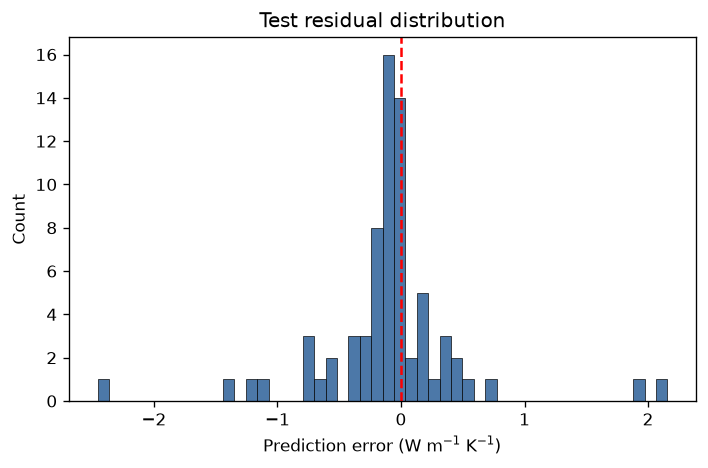

Saved: basic_gnn_test_residual_hist.png


In [20]:
# Cell 20 - Residual distribution của test set
test_true, test_pred, test_row_ids = prediction_sets["Test"]
test_residuals = test_pred - test_true

plt.figure(figsize=(6, 4), dpi=120)
plt.hist(test_residuals, bins=50, color="#4C78A8", edgecolor="black", linewidth=0.4)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel(r"Prediction error (W m$^{-1}$ K$^{-1}$)")
plt.ylabel("Count")
plt.title("Test residual distribution")
plt.tight_layout()
plt.savefig("basic_gnn_test_residual_hist.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: basic_gnn_test_residual_hist.png")


In [ ]:
# Cell 21 - Lưu metrics, parity data và test residual để vẽ lại bằng Origin
parity_frames = []

for dataset_name, (y_true_set, y_pred_set, row_ids_set) in prediction_sets.items():
    metadata = df_work.iloc[row_ids_set].reset_index(drop=True).copy()
    keep_columns = [
        column for column in [
            "identifier", "formula", "Formula_original", "Temperature (K)",
            "TC", "DOI", "cif_path", "resolved_cif_path"
        ] if column in metadata.columns
    ]
    frame = metadata[keep_columns].copy()
    frame.insert(0, "Dataset", dataset_name)
    frame["TC_true"] = y_true_set
    frame["TC_predicted"] = y_pred_set
    frame["residual"] = y_pred_set - y_true_set
    frame["abs_error"] = np.abs(frame["residual"])
    parity_frames.append(frame)

parity_data_df = pd.concat(parity_frames, ignore_index=True)
test_residual_df = parity_data_df[parity_data_df["Dataset"] == "Test"].reset_index(drop=True).copy()

metrics_output_df = metrics_df.copy()
metrics_output_df.insert(0, "Model", "Basic GNN + Temperature")
metrics_output_df["Split_mode"] = SPLIT_MODE

parity_data_df.to_csv("Basic_GNN_parity_data_train_validation_test.csv", index=False)
test_residual_df.to_csv("Basic_GNN_test_residuals.csv", index=False)
metrics_output_df.to_csv("Basic_GNN_TC_metrics.csv", index=False)

print("Saved: Basic_GNN_parity_data_train_validation_test.csv")
print("Saved: Basic_GNN_test_residuals.csv")
print("Saved: Basic_GNN_TC_metrics.csv")
display(metrics_output_df.round(6))
display(test_residual_df.head())


In [ ]:
# Experimental validation bằng Materials Project API
# Input CSV bắt buộc có ba cột: Formula, Temperature, TC.
EXPERIMENTAL_CSV_PATH = r"experimental_validation.csv"
EXPERIMENTAL_OUTPUT_PATH = "Basic_GNN_experimental_predictions.csv"
MP_CIF_OUTPUT_DIR = "MP_experimental_CIF"

# mp-api là client chính thức của Materials Project.
if importlib.util.find_spec("mp_api") is None:
    pip_install("mp-api")

from getpass import getpass
from mp_api.client import MPRester
from pymatgen.core import Composition
from pymatgen.io.ase import AseAtomsAdaptor


def get_mp_api_key():
    key = os.environ.get("MP_API_KEY") or os.environ.get("PMG_MAPI_KEY")
    if key:
        return key.strip()
    key = getpass("Materials Project API key: ").strip()
    if not key:
        raise ValueError("Chưa cung cấp Materials Project API key.")
    return key


def select_lowest_formation_energy_structure(mpr, formula):
    """Query đúng composition và chọn polymorph có formation energy/atom nhỏ nhất."""
    target_composition = Composition(formula).reduced_composition
    documents = mpr.materials.summary.search(
        formula=formula,
        fields=[
            "material_id",
            "formula_pretty",
            "formation_energy_per_atom",
            "energy_above_hull",
            "structure",
        ],
    )

    exact_documents = [
        document for document in documents
        if document.structure is not None
        and document.structure.composition.reduced_composition == target_composition
        and document.formation_energy_per_atom is not None
    ]
    if not exact_documents:
        raise ValueError(f"Materials Project không có structure hợp lệ cho Formula={formula}")

    selected = min(exact_documents, key=lambda document: float(document.formation_energy_per_atom))
    return selected, len(exact_documents)


experimental_df = pd.read_csv(EXPERIMENTAL_CSV_PATH)
required_external_columns = ["Formula", "Temperature", "TC"]
missing_external_columns = [c for c in required_external_columns if c not in experimental_df.columns]
if missing_external_columns:
    raise ValueError(f"Experimental CSV thiếu cột: {missing_external_columns}")

experimental_df = experimental_df.copy()
experimental_df["Formula"] = experimental_df["Formula"].astype(str).str.strip()
experimental_df["Temperature"] = pd.to_numeric(experimental_df["Temperature"], errors="coerce")
experimental_df["TC"] = pd.to_numeric(experimental_df["TC"], errors="coerce")
invalid_mask = experimental_df[["Formula", "Temperature", "TC"]].isna().any(axis=1)
if invalid_mask.any():
    raise ValueError(f"Experimental CSV có giá trị thiếu/không hợp lệ tại dòng: {experimental_df.index[invalid_mask].tolist()}")

os.makedirs(MP_CIF_OUTPUT_DIR, exist_ok=True)
api_key = get_mp_api_key()
formula_cache = {}
query_failures = []

with MPRester(api_key) as mpr:
    for formula in experimental_df["Formula"].drop_duplicates():
        try:
            document, number_of_candidates = select_lowest_formation_energy_structure(mpr, formula)
            material_id = str(document.material_id)
            safe_formula = re.sub(r"[^A-Za-z0-9_.-]+", "_", formula)
            cif_path = os.path.join(MP_CIF_OUTPUT_DIR, f"{safe_formula}_{material_id}.cif")
            document.structure.to(filename=cif_path)

            formula_cache[formula] = {
                "material_id": material_id,
                "formation_energy_per_atom": float(document.formation_energy_per_atom),
                "energy_above_hull": (
                    float(document.energy_above_hull)
                    if document.energy_above_hull is not None else np.nan
                ),
                "number_of_candidates": number_of_candidates,
                "cif_path": cif_path,
                "structure": document.structure,
            }
        except Exception as error:
            query_failures.append({"Formula": formula, "error": str(error)})

if query_failures:
    display(pd.DataFrame(query_failures))
    raise ValueError("Không thể lấy CIF hợp lệ cho một hoặc nhiều Formula; xem bảng lỗi phía trên.")

experimental_graphs = []
for row_id, row in experimental_df.iterrows():
    selected = formula_cache[row["Formula"]]
    atoms = AseAtomsAdaptor.get_atoms(selected["structure"])
    graph = atoms_to_graph(atoms, r_cut=R_CUT, max_neighbors=MAX_NEIGHBORS)
    graph.temperature = torch.tensor([float(row["Temperature"])], dtype=torch.float32)
    graph.y = torch.tensor([float(row["TC"])], dtype=torch.float32)
    graph.row_id = torch.tensor([row_id], dtype=torch.long)
    experimental_graphs.append(graph)

experimental_loader = DataLoader(experimental_graphs, batch_size=BATCH_SIZE, shuffle=False)
_, experimental_prediction, experimental_row_ids = predict_loader(model, experimental_loader)

experimental_output = experimental_df.iloc[experimental_row_ids].reset_index(drop=True).copy()
experimental_output["material_id"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["material_id"]
)
experimental_output["formation_energy_per_atom"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["formation_energy_per_atom"]
)
experimental_output["energy_above_hull"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["energy_above_hull"]
)
experimental_output["MP_candidates"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["number_of_candidates"]
)
experimental_output["selected_cif_path"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["cif_path"]
)
experimental_output["TC_predicted"] = experimental_prediction
experimental_output["residual"] = experimental_output["TC_predicted"] - experimental_output["TC"]
experimental_output["abs_error"] = experimental_output["residual"].abs()
experimental_output.to_csv(EXPERIMENTAL_OUTPUT_PATH, index=False)

experimental_metrics = {
    "Model": "Basic GNN + Temperature",
    "R2": r2_score(experimental_output["TC"], experimental_output["TC_predicted"]),
    "RMSE": np.sqrt(mean_squared_error(experimental_output["TC"], experimental_output["TC_predicted"])),
    "MAE": mean_absolute_error(experimental_output["TC"], experimental_output["TC_predicted"]),
}
print("Experimental metrics:", experimental_metrics)
print("Saved selected CIF files in:", MP_CIF_OUTPUT_DIR)
print("Saved:", EXPERIMENTAL_OUTPUT_PATH)
display(experimental_output.head())


## So sánh với CGCNN

| Thành phần | Basic GNN trong notebook này | CGCNN trong notebook gốc |
|---|---|---|
| Node input | Embedding của số hiệu nguyên tử | Embedding của số hiệu nguyên tử |
| Edge | Quan hệ lân cận | Quan hệ lân cận + khoảng cách Gaussian |
| Message passing | `GCNConv` chuẩn hóa theo bậc nút | Gated convolution sử dụng đặc trưng cạnh |
| Pooling | Global mean pooling | Mean pooling |
| Global input | Temperature (K) | Temperature (K) |
| Target | TC thật, không scale | TC thật, không scale |

Để so sánh công bằng với notebook CGCNN đã cung cấp, giữ `SPLIT_MODE="row"`, `SEED=42`, tỷ lệ 80/10/10 và cùng số epoch. Nếu mục tiêu là đánh giá khả năng dự đoán cấu trúc chưa từng xuất hiện, dùng `SPLIT_MODE="structure"` cho cả hai mô hình.
